In [182]:
print("reck98")
!(which python)
!(python --version)

reck98
/run/media/reck98/Others/Development/ML_NLP_DL/Ml-algorithms/.venv/bin/python
Python 3.12.12


In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path as FilePath
import tqdm
import warnings

warnings.filterwarnings('ignore')

In [184]:
FILE_PATH = FilePath("../../public/ford.csv")

In [185]:
orginal_df = pd.read_csv(FILE_PATH)
orginal_df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [186]:
df = orginal_df.copy()
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [187]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [188]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  str    
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  str    
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  str    
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 1.2 MB


In [189]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [190]:
categoricalCols = [col for col in df.columns if df[col].dtype in ["str"]]
categoricalCols

['model', 'transmission', 'fuelType']

In [191]:
numericCols = [col for col in df.columns if df[col].dtype not in ["str"]]
numericCols

['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']

In [192]:
print(f"Numeric Cols: {len(numericCols)}")
print(f"Categoical Cols: {len(categoricalCols)}")
print(f"Total Cols: {len(df.columns)}")

Numeric Cols: 6
Categoical Cols: 3
Total Cols: 9


Minimum Value: 1996
Q1: 2016.0
Median: 2017.0
Q3: 2018.0
Maximum Value: 2060


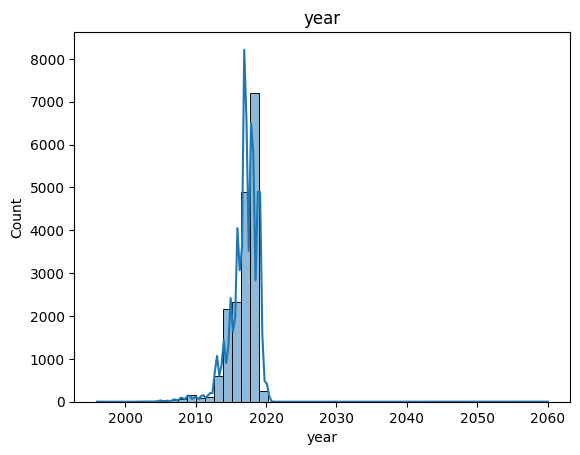


Minimum Value: 495
Q1: 8999.0
Median: 11291.0
Q3: 15299.0
Maximum Value: 54995


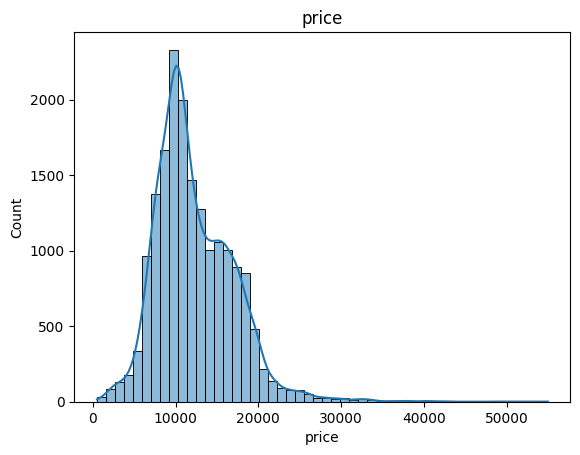


Minimum Value: 1
Q1: 9987.0
Median: 18242.5
Q3: 31060.0
Maximum Value: 177644


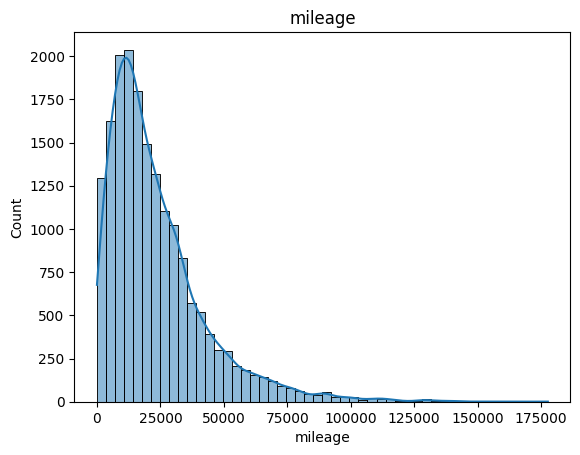


Minimum Value: 0
Q1: 30.0
Median: 145.0
Q3: 145.0
Maximum Value: 580


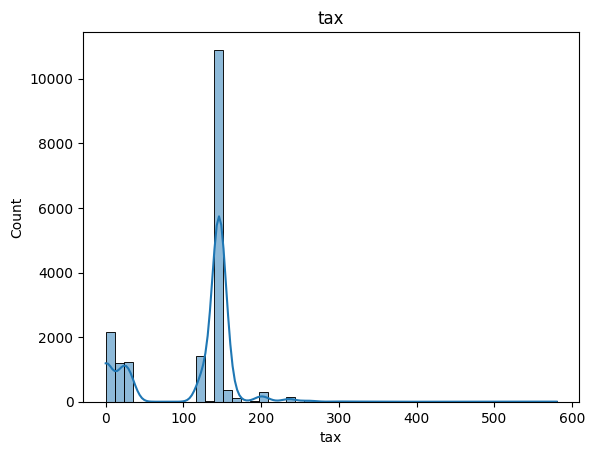


Minimum Value: 20.8
Q1: 52.3
Median: 58.9
Q3: 65.7
Maximum Value: 201.8


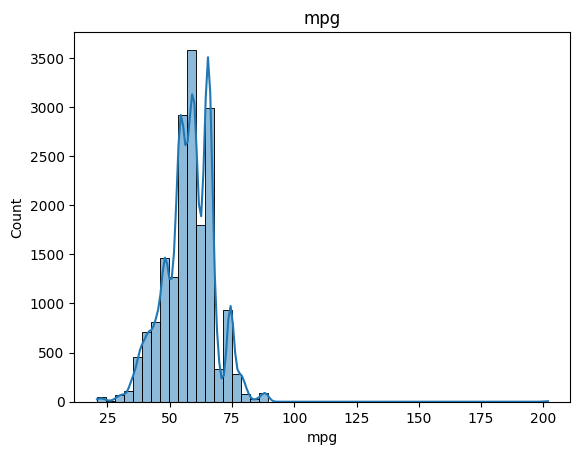


Minimum Value: 0.0
Q1: 1.0
Median: 1.2
Q3: 1.5
Maximum Value: 5.0


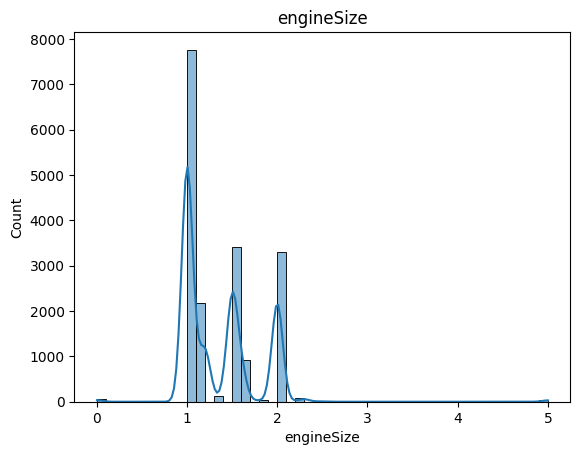

In [193]:
def fiveNumberSummary(col):
    minVal = df[col].min()
    maxVal = df[col].max()
    q1 = df[col].quantile(0.25)
    medianVal = df[col].median()
    q3 = df[col].quantile(0.75)
    
    print(f"Minimum Value: {minVal}")
    print(f"Q1: {q1}")
    print(f"Median: {medianVal}")
    print(f"Q3: {q3}")
    print(f"Maximum Value: {maxVal}")
    
    return minVal, q1, medianVal, q3, maxVal

for col in numericCols:
    sns.histplot(df[col], kde = True, bins=50)
    plt.xlabel(col)
    plt.title(col)
    fiveNumberSummary(col)
    plt.show()
    print("")
    

In [194]:
df['engineSize'].value_counts()

engineSize
1.0    7765
1.5    3418
2.0    3311
1.2    1626
1.6     923
1.1     559
1.4     112
2.3      80
0.0      51
5.0      45
1.8      35
2.2      13
2.5      13
1.3      13
3.2       1
1.7       1
Name: count, dtype: int64

<Axes: >

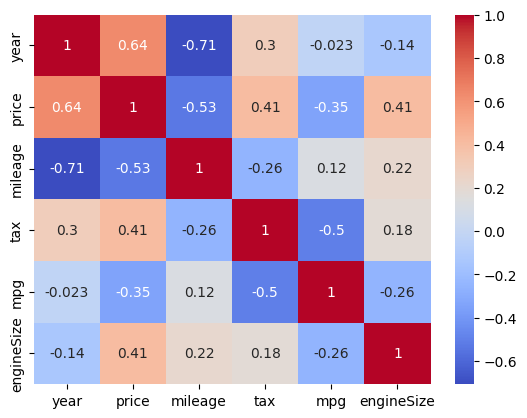

In [195]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 [Text(0, 0, '1996'),
  Text(1, 0, '1998'),
  Text(2, 0, '2000'),
  Text(3, 0, '2002'),
  Text(4, 0, '2003'),
  Text(5, 0, '2004'),
  Text(6, 0, '2005'),
  Text(7, 0, '2006'),
  Text(8, 0, '2007'),
  Text(9, 0, '2008'),
  Text(10, 0, '2009'),
  Text(11, 0, '2010'),
  Text(12, 0, '2011'),
  Text(13, 0, '2012'),
  Text(14, 0, '2013'),
  Text(15, 0, '2014'),
  Text(16, 0, '2015'),
  Text(17, 0, '2016'),
  Text(18, 0, '2017'),
  Text(19, 0, '2018'),
  Text(20, 0, '2019'),
  Text(21, 0, '2020'),
  Text(22, 0, '2060')])

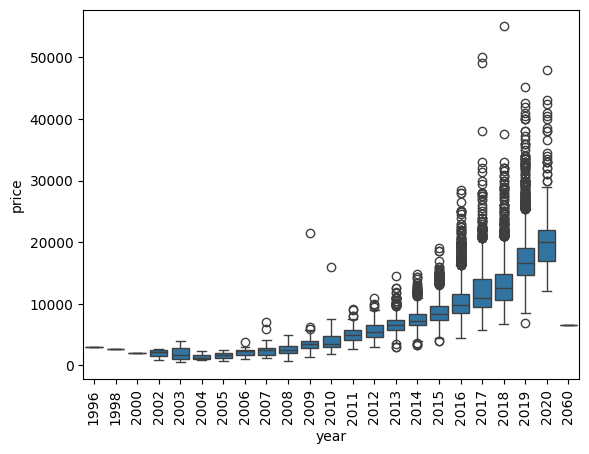

In [196]:
sns.boxplot(data=df, x = 'year', y='price')
plt.xticks(rotation = 90)

<Axes: xlabel='mileage', ylabel='price'>

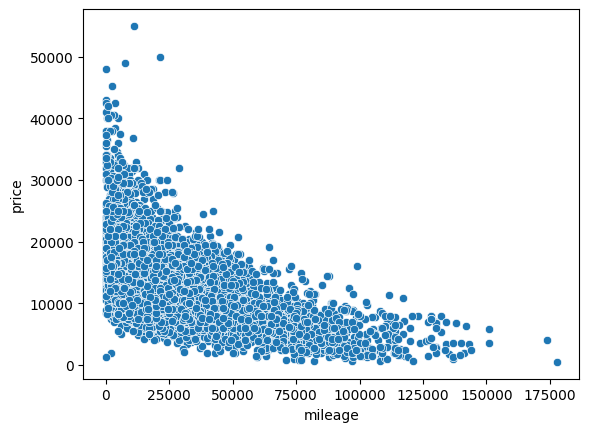

In [197]:
sns.scatterplot(data=df, x = 'mileage', y='price')

<Axes: xlabel='engineSize', ylabel='price'>

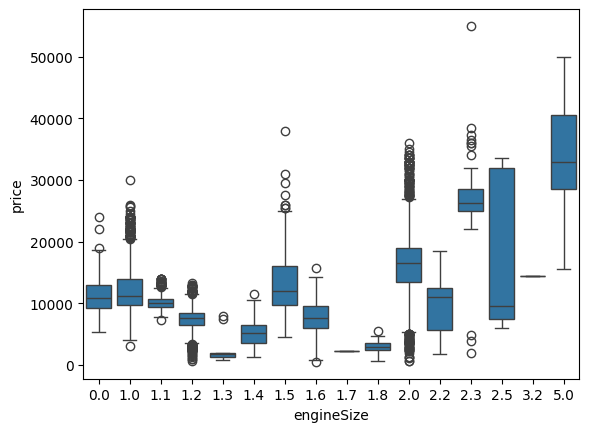

In [198]:
sns.boxplot(data=df, x = 'engineSize', y='price')

['model', 'transmission', 'fuelType']

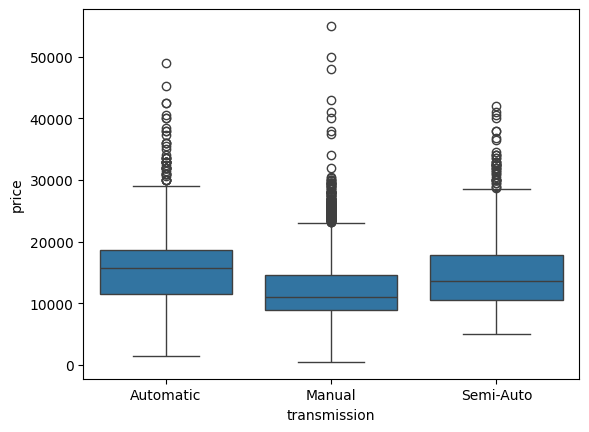

In [199]:
sns.boxplot(data=df, x = 'transmission', y='price')
categoricalCols

<Axes: xlabel='fuelType', ylabel='price'>

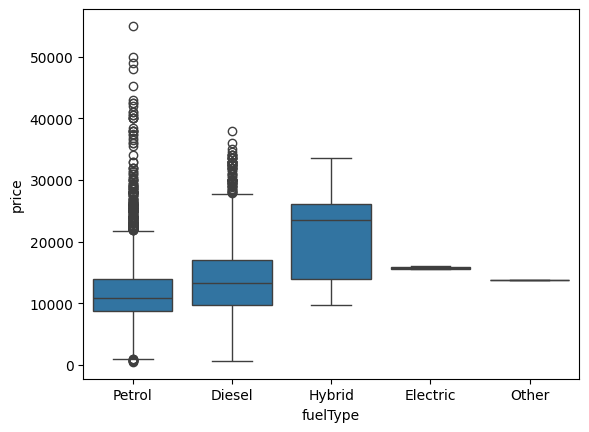

In [200]:
sns.boxplot(data=df, x = 'fuelType', y='price')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, ' Fiesta'),
  Text(1, 0, ' Focus'),
  Text(2, 0, ' Puma'),
  Text(3, 0, ' Kuga'),
  Text(4, 0, ' EcoSport'),
  Text(5, 0, ' C-MAX'),
  Text(6, 0, ' Mondeo'),
  Text(7, 0, ' Ka+'),
  Text(8, 0, ' Tourneo Custom'),
  Text(9, 0, ' S-MAX'),
  Text(10, 0, ' B-MAX'),
  Text(11, 0, ' Edge'),
  Text(12, 0, ' Tourneo Connect'),
  Text(13, 0, ' Grand C-MAX'),
  Text(14, 0, ' KA'),
  Text(15, 0, ' Galaxy'),
  Text(16, 0, ' Mustang'),
  Text(17, 0, ' Grand Tourneo Connect'),
  Text(18, 0, ' Fusion'),
  Text(19, 0, ' Ranger'),
  Text(20, 0, ' Streetka'),
  Text(21, 0, ' Escort'),
  Text(22, 0, ' Transit Tourneo'),
  Text(23, 0, 'Focus')])

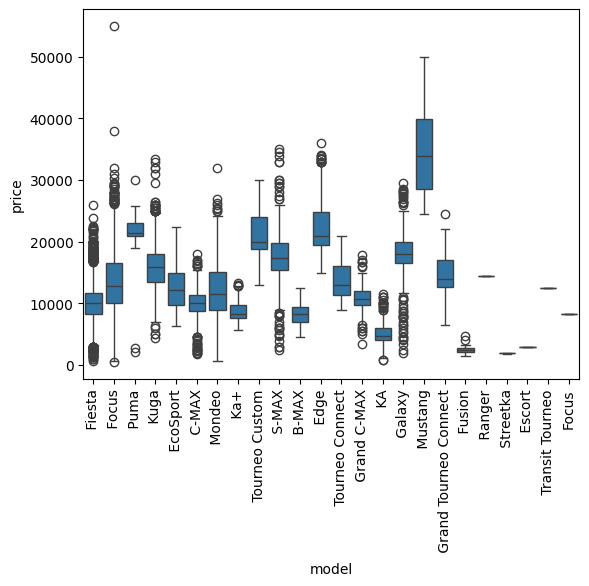

In [201]:
sns.boxplot(data=df, x = 'model', y='price')
plt.xticks(rotation = 90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35],
 [Text(0, 0, '0'),
  Text(1, 0, '20'),
  Text(2, 0, '22'),
  Text(3, 0, '30'),
  Text(4, 0, '110'),
  Text(5, 0, '115'),
  Text(6, 0, '120'),
  Text(7, 0, '125'),
  Text(8, 0, '135'),
  Text(9, 0, '140'),
  Text(10, 0, '145'),
  Text(11, 0, '150'),
  Text(12, 0, '155'),
  Text(13, 0, '160'),
  Text(14, 0, '165'),
  Text(15, 0, '185'),
  Text(16, 0, '190'),
  Text(17, 0, '195'),
  Text(18, 0, '200'),
  Text(19, 0, '205'),
  Text(20, 0, '210'),
  Text(21, 0, '220'),
  Text(22, 0, '230'),
  Text(23, 0, '235'),
  Text(24, 0, '240'),
  Text(25, 0, '260'),
  Text(26, 0, '265'),
  Text(27, 0, '270'),
  Text(28, 0, '290'),
  Text(29, 0, '300'),
  Text(30, 0, '305'),
  Text(31, 0, '325'),
  Text(32, 0, '330'),
  Text(33, 0, '555'),
  Text(34, 0, '570'),
  Text(35, 0, '580')])

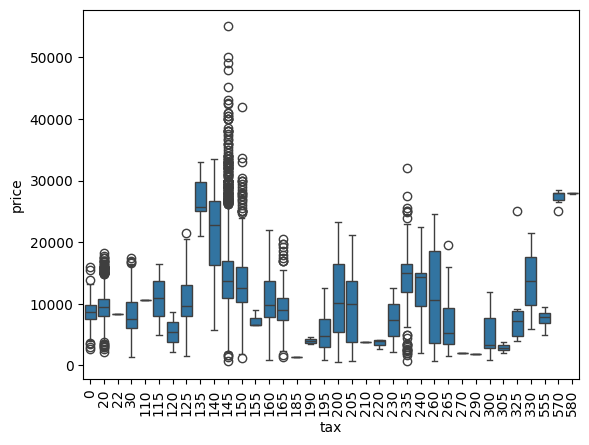

In [202]:
sns.boxplot(data=df, x = 'tax', y='price')
plt.xticks(rotation = 90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89],
 [Text(0, 0, '20.8'),
  Text(1, 0, '20.9'),
  Text(2, 0, '22.1'),
  Text(3, 0, '22.6'),
  Text(4, 0, '22.8'),
  Text(5, 0, '23.5'),
  Text(6, 0, '23.7'),
  Text(7, 0, '23.9'),
  Text(8, 0, '24.8'),
  Text(9, 0, '26.3'),
  Text(10, 0, '27.4'),
  Text(11, 0, '28.0'),
  Text(12, 0, '28.3'),
  Text(13, 0, '28.5'),
  Text(14, 0, '28.8'),
  Text(15, 0, '29.1'),
  Text(16, 0, '29.4'),
  Text(17, 0, '30.1'),
  Text(18, 0, '30.4'),
  Text(19, 0, '30.7'),
  Text(20, 0, '31.0

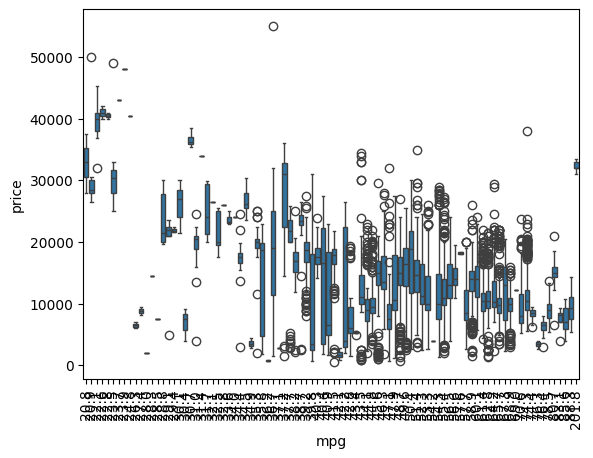

In [203]:
sns.boxplot(data=df, x = 'mpg', y='price')
plt.xticks(rotation = 90)

In [204]:
X = df.drop("price", axis=1)
y = df["price"]

In [205]:
print(X.head())
print(y.head())

     model  year transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019    Automatic     1482   Petrol  145  48.7         1.0
0    12000
1    14000
2    13000
3    17500
4    16500
Name: price, dtype: int64


In [206]:
categoricalCols

['model', 'transmission', 'fuelType']

In [207]:
X_one_hot_encoding = X.copy()

In [208]:
X_one_hot_encoding = pd.get_dummies(X_one_hot_encoding,columns=categoricalCols , drop_first=True)

for col in X_one_hot_encoding.columns:
    if X_one_hot_encoding[col].dtype == "bool":
        X_one_hot_encoding[col] = X_one_hot_encoding[col].astype(int)

X_one_hot_encoding.head()

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57.7,1.0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,2018,9083,150,57.7,1.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,12456,150,57.7,1.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,10460,145,40.3,1.5,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,2019,1482,145,48.7,1.0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


In [209]:
X_label_encoding = X.copy()

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in categoricalCols:
    X_label_encoding[col] = encoder.fit_transform(X_label_encoding[col])

X_label_encoding.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0


In [210]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [211]:
X_label_encoding.info()

labelCols = [col for col in X_label_encoding.columns if X_label_encoding[col].dtype in ["int64", "float64"]]
labelCols

<class 'pandas.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  int64  
 1   year          17966 non-null  int64  
 2   transmission  17966 non-null  int64  
 3   mileage       17966 non-null  int64  
 4   fuelType      17966 non-null  int64  
 5   tax           17966 non-null  int64  
 6   mpg           17966 non-null  float64
 7   engineSize    17966 non-null  float64
dtypes: float64(2), int64(6)
memory usage: 1.1 MB


['model',
 'year',
 'transmission',
 'mileage',
 'fuelType',
 'tax',
 'mpg',
 'engineSize']

In [212]:
X_label_encoding[labelCols] = scaler.fit_transform(X_label_encoding[labelCols])
X_label_encoding.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460699,0.065128,-2.670032,-0.380998,0.688777,0.591358,-0.020442,-0.811386
1,-0.211477,0.552866,0.041351,-0.733359,0.688777,0.591358,-0.020442,-0.811386
2,-0.211477,0.065128,0.041351,-0.560132,0.688777,0.591358,-0.020442,-0.811386
3,-0.460699,1.040605,0.041351,-0.662640,0.688777,0.510727,-1.738890,0.345070
4,-0.460699,1.040605,-2.670032,-1.123724,0.688777,0.510727,-0.909294,-0.811386


In [213]:
X_one_hot_encoding.head()

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57.7,1.0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,2018,9083,150,57.7,1.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,12456,150,57.7,1.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,10460,145,40.3,1.5,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,2019,1482,145,48.7,1.0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


In [214]:
oneHotEncodingCols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
oneHotEncodingCols

['year', 'mileage', 'tax', 'mpg', 'engineSize']

In [215]:
X_one_hot_encoding[oneHotEncodingCols] = scaler.fit_transform(X_one_hot_encoding[oneHotEncodingCols])
X_one_hot_encoding.head()

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.065128,-0.380998,0.591358,-0.020442,-0.811386,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,0.552866,-0.733359,0.591358,-0.020442,-0.811386,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.065128,-0.560132,0.591358,-0.020442,-0.811386,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,1.040605,-0.662640,0.510727,-1.738890,0.345070,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,1.040605,-1.123724,0.510727,-0.909294,-0.811386,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


In [216]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def adjusted_r2_score(r2, n, p):
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    return adjusted_r2




In [217]:
model = LinearRegression()

X_label_encoding_train, X_label_encoding_test, y_label_encoding_train, y_label_encoding_test = train_test_split(X_label_encoding, y, test_size=0.2, random_state=42)

model.fit(X_label_encoding_train, y_label_encoding_train)

y_label_encoding_pred = model.predict(X_label_encoding_test)

mse = mean_squared_error(y_label_encoding_test, y_label_encoding_pred)
mae = mean_absolute_error(y_label_encoding_test, y_label_encoding_pred)
r2 = r2_score(y_label_encoding_test, y_label_encoding_pred)
adjusted_r2 = adjusted_r2_score(r2, len(y_label_encoding_test), len(X_label_encoding.columns))

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R2 Score: {r2}")
print(f"Adjusted R2 Score: {adjusted_r2}")

Mean Squared Error: 5903593.744919552
Mean Absolute Error: 1776.8255281707002
R2 Score: 0.7365884288851352
Adjusted R2 Score: 0.7360006206371801


In [218]:
model2 = LinearRegression()

X_one_hot_encoding_train, X_one_hot_encoding_test, y_one_hot_encoding_train, y_one_hot_encoding_test = train_test_split(X_one_hot_encoding, y, test_size=0.2, random_state=42)

model2.fit(X_one_hot_encoding_train, y_one_hot_encoding_train)

y_one_hot_encoding_pred = model2.predict(X_one_hot_encoding_test)

mse = mean_squared_error(y_one_hot_encoding_test, y_one_hot_encoding_pred)
mae = mean_absolute_error(y_one_hot_encoding_test, y_one_hot_encoding_pred)
r2 = r2_score(y_one_hot_encoding_test, y_one_hot_encoding_pred)
adjusted_r2 = adjusted_r2_score(r2, len(y_one_hot_encoding_test), len(X_one_hot_encoding.columns))

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R2 Score: {r2}")
print(f"Adjusted R2 Score: {adjusted_r2}")

i = 0
for col in X_one_hot_encoding.columns:
    print(f"{i} > {col}")
    i += 1

Mean Squared Error: 3454991.9817439793
Mean Absolute Error: 1374.8110353356635
R2 Score: 0.8458422267142565
Adjusted R2 Score: 0.8443695196921392
0 > year
1 > mileage
2 > tax
3 > mpg
4 > engineSize
5 > model_ C-MAX
6 > model_ EcoSport
7 > model_ Edge
8 > model_ Escort
9 > model_ Fiesta
10 > model_ Focus
11 > model_ Fusion
12 > model_ Galaxy
13 > model_ Grand C-MAX
14 > model_ Grand Tourneo Connect
15 > model_ KA
16 > model_ Ka+
17 > model_ Kuga
18 > model_ Mondeo
19 > model_ Mustang
20 > model_ Puma
21 > model_ Ranger
22 > model_ S-MAX
23 > model_ Streetka
24 > model_ Tourneo Connect
25 > model_ Tourneo Custom
26 > model_ Transit Tourneo
27 > model_Focus
28 > transmission_Manual
29 > transmission_Semi-Auto
30 > fuelType_Electric
31 > fuelType_Hybrid
32 > fuelType_Other
33 > fuelType_Petrol


In [219]:
import pickle

with open('car-price-prediction-model.pkl', 'wb') as f:
    pickle.dump(model2, f)